<a href="https://colab.research.google.com/github/saadmansakib75/Data_Science-and-Machine-Learnig/blob/main/EDA_Project_(insurance_dataset).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/insurance.csv")

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.isnull()

,age,sex,bmi,children,smoker,region,charges
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
1333,False,False,False,False,False,False,False
1334,False,False,False,False,False,False,False
1335,False,False,False,False,False,False,False
1336,False,False,False,False,False,False,False


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

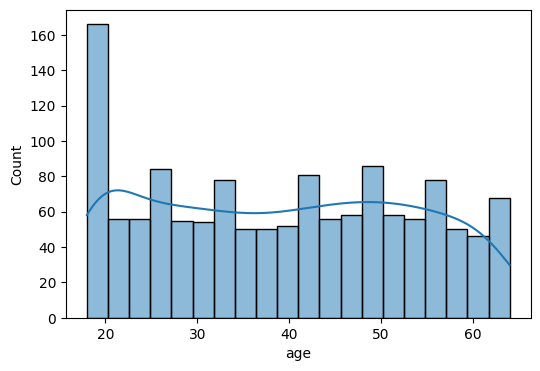

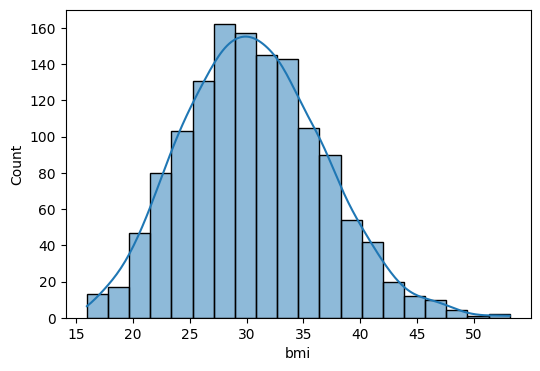

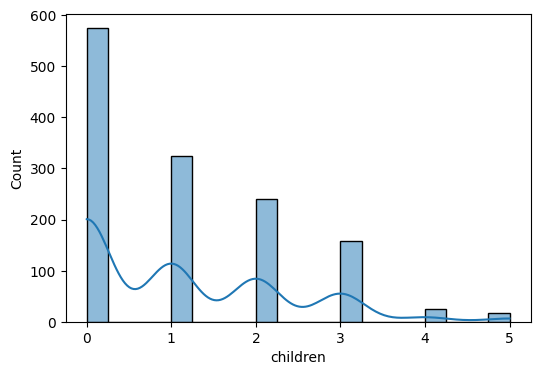

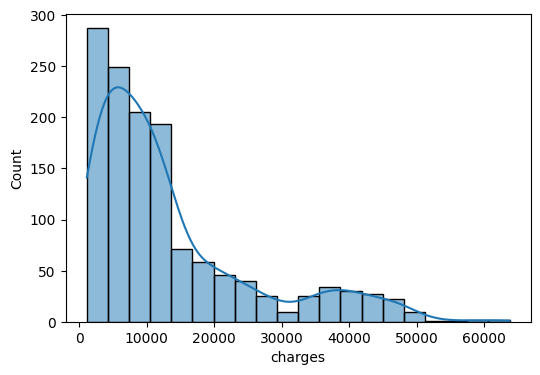

In [ ]:
numeric_col = ['age', 'bmi', 'children', 'charges']
for col in numeric_col:
  plt.figure(figsize=(6,4))
  sns.histplot(df[col],kde=True, bins=20)

<Axes: xlabel='children', ylabel='count'>

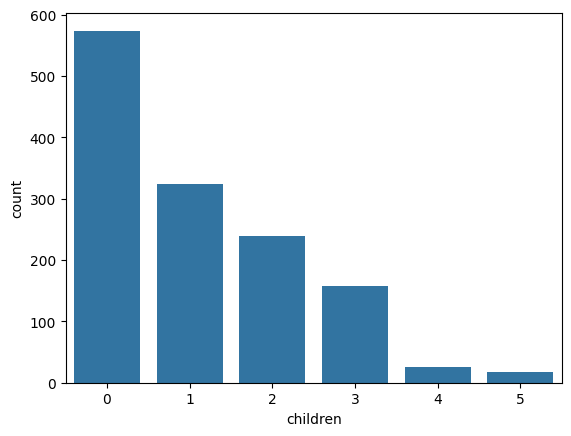

In [ ]:
 sns.countplot(x = df['children'])

<Axes: xlabel='sex', ylabel='count'>

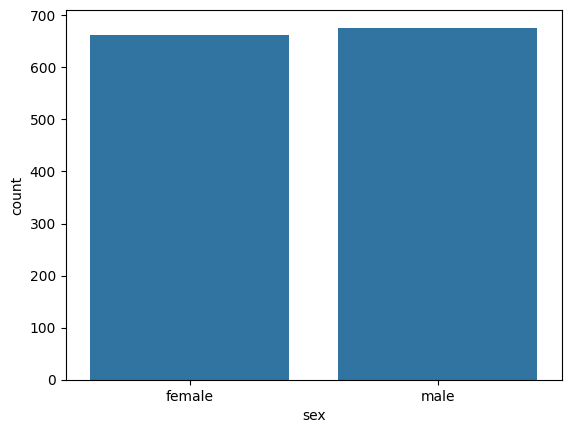

In [ ]:
 sns.countplot(x = df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

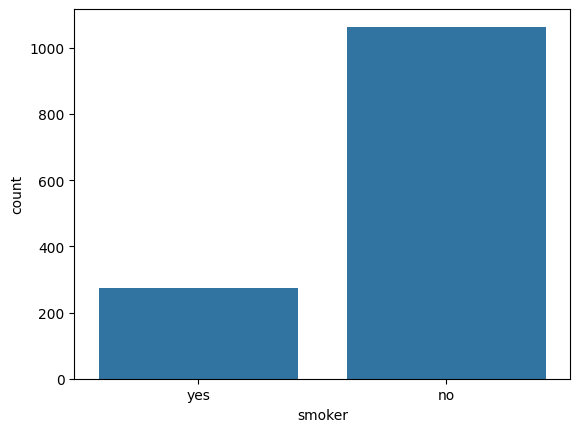

In [ ]:
 sns.countplot(x = df['smoker'])

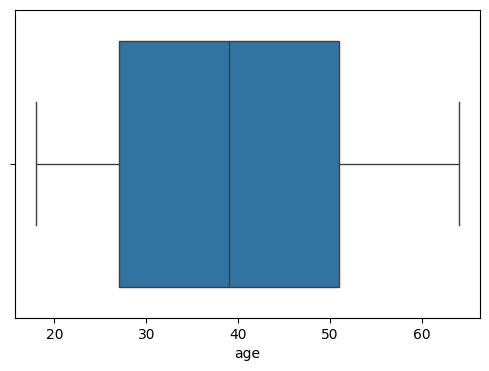

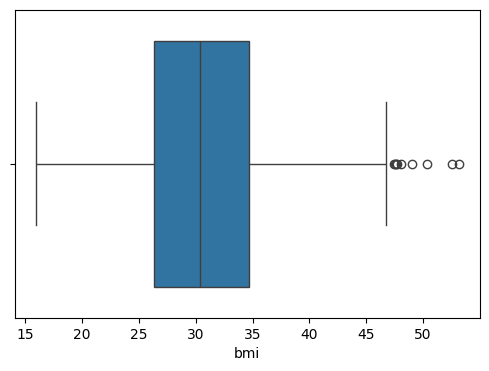

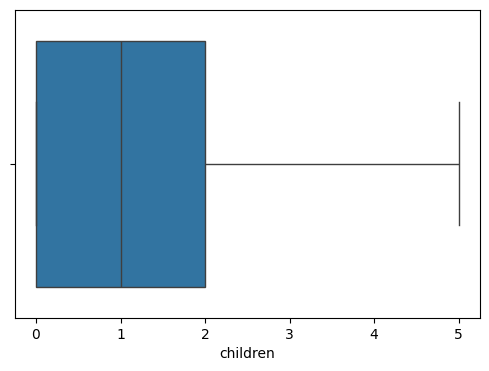

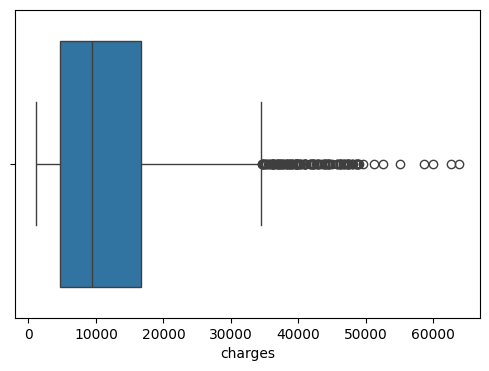

In [ ]:
for col in numeric_col:
  plt.figure(figsize=(6,4))
  sns.boxplot(x = df[col])

<Axes: >

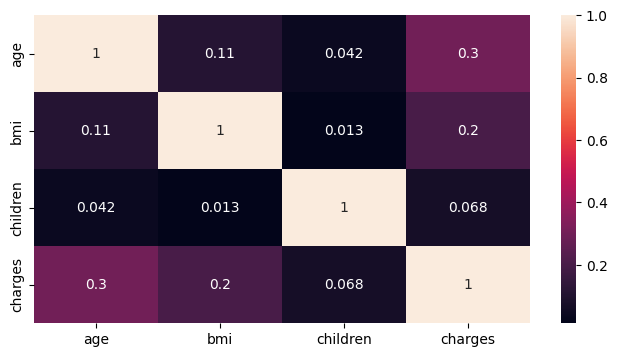

In [ ]:
plt.figure(figsize=(8,4))
sns.heatmap(df.corr(numeric_only=True), annot = True)

In [ ]:
df_cleaned = df.copy()

In [ ]:
df_cleaned

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [ ]:
df_cleaned.shape

(1338, 7)

In [ ]:
df_cleaned.drop_duplicates(inplace = True)

In [ ]:
df.shape

(1338, 7)

In [ ]:
df_cleaned['sex'].value_counts()

,count
sex,
male,675
female,662


In [ ]:
df_cleaned['sex'] = df_cleaned['sex'].map({"male": 0, "female": 1})

In [ ]:
df_cleaned['smoker'].value_counts()

,count
smoker,
no,1063
yes,274


In [ ]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({"no" : 1, "yes" : 0})

In [ ]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,0,southwest,16884.92400
1,18,0,33.770,1,1,southeast,1725.55230
2,28,0,33.000,3,1,southeast,4449.46200
3,33,0,22.705,0,1,northwest,21984.47061
4,32,0,28.880,0,1,northwest,3866.85520


In [ ]:
df_cleaned.rename(columns={
    'sex' : 'is_female',
    'smoker' : 'is_smoker'
}, inplace=True)

In [ ]:
df_cleaned

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,0,southwest,16884.92400
1,18,0,33.770,1,1,southeast,1725.55230
2,28,0,33.000,3,1,southeast,4449.46200
3,33,0,22.705,0,1,northwest,21984.47061
4,32,0,28.880,0,1,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,1,northwest,10600.54830
1334,18,1,31.920,0,1,northeast,2205.98080
1335,18,1,36.850,0,1,southeast,1629.83350
1336,21,1,25.800,0,1,southwest,2007.94500


In [ ]:
df_cleaned['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,324
northeast,324


In [ ]:
df_cleaned

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,0,southwest,16884.92400
1,18,0,33.770,1,1,southeast,1725.55230
2,28,0,33.000,3,1,southeast,4449.46200
3,33,0,22.705,0,1,northwest,21984.47061
4,32,0,28.880,0,1,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,1,northwest,10600.54830
1334,18,1,31.920,0,1,northeast,2205.98080
1335,18,1,36.850,0,1,southeast,1629.83350
1336,21,1,25.800,0,1,southwest,2007.94500


In [ ]:
df_cleaned = pd.get_dummies(df_cleaned,columns=['region'],drop_first=True)

In [ ]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,0,16884.92400,False,False,True
1,18,0,33.770,1,1,1725.55230,False,True,False
2,28,0,33.000,3,1,4449.46200,False,True,False
3,33,0,22.705,0,1,21984.47061,True,False,False
4,32,0,28.880,0,1,3866.85520,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,1,10600.54830,True,False,False
1334,18,1,31.920,0,1,2205.98080,False,False,False
1335,18,1,36.850,0,1,1629.83350,False,True,False
1336,21,1,25.800,0,1,2007.94500,False,False,True


In [ ]:
df_cleaned = df_cleaned.astype(int)

In [ ]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,0,16884,0,0,1
1,18,0,33,1,1,1725,0,1,0
2,28,0,33,3,1,4449,0,1,0
3,33,0,22,0,1,21984,1,0,0
4,32,0,28,0,1,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,1,10600,1,0,0
1334,18,1,31,0,1,2205,0,0,0
1335,18,1,36,0,1,1629,0,1,0
1336,21,1,25,0,1,2007,0,0,1


#Feature Engineering and Extraction





In [ ]:
df_cleaned['bmi_category'] = pd.cut(
     df_cleaned['bmi'],
     bins =[0, 18.5, 24.9, 29.9, float('inf')],
     labels=['underweight', 'normal', 'overweight', 'obese']

 )

In [ ]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,0,16884,0,0,1,overweight
1,18,0,33,1,1,1725,0,1,0,obese
2,28,0,33,3,1,4449,0,1,0,obese
3,33,0,22,0,1,21984,1,0,0,normal
4,32,0,28,0,1,3866,1,0,0,overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,1,10600,1,0,0,obese
1334,18,1,31,0,1,2205,0,0,0,obese
1335,18,1,36,0,1,1629,0,1,0,obese
1336,21,1,25,0,1,2007,0,0,1,overweight


In [ ]:
df_cleaned = pd.get_dummies(df_cleaned,columns=['bmi_category'],drop_first=True)

In [ ]:
df_cleaned = df_cleaned.astype(int)

In [ ]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,19,1,27,0,0,16884,0,0,1,0,1,0
1,18,0,33,1,1,1725,0,1,0,0,0,1
2,28,0,33,3,1,4449,0,1,0,0,0,1
3,33,0,22,0,1,21984,1,0,0,1,0,0
4,32,0,28,0,1,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,1,10600,1,0,0,0,0,1
1334,18,1,31,0,1,2205,0,0,0,0,0,1
1335,18,1,36,0,1,1629,0,1,0,0,0,1
1336,21,1,25,0,1,2007,0,0,1,0,1,0


In [ ]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_normal', 'bmi_category_overweight', 'bmi_category_obese'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_cleaned[['age', 'bmi', 'children']] = scaler.fit_transform(
    df_cleaned[['age', 'bmi', 'children']]
)

In [ ]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,-1.440418,1,-0.517949,-0.909234,0,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,1,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,1,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,1,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,1,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,1,10600,1,0,0,0,0,1
1334,-1.511647,1,0.135659,-0.909234,1,2205,0,0,0,0,0,1
1335,-1.511647,1,0.952670,-0.909234,1,1629,0,1,0,0,0,1
1336,-1.297958,1,-0.844753,-0.909234,1,2007,0,0,1,0,1,0


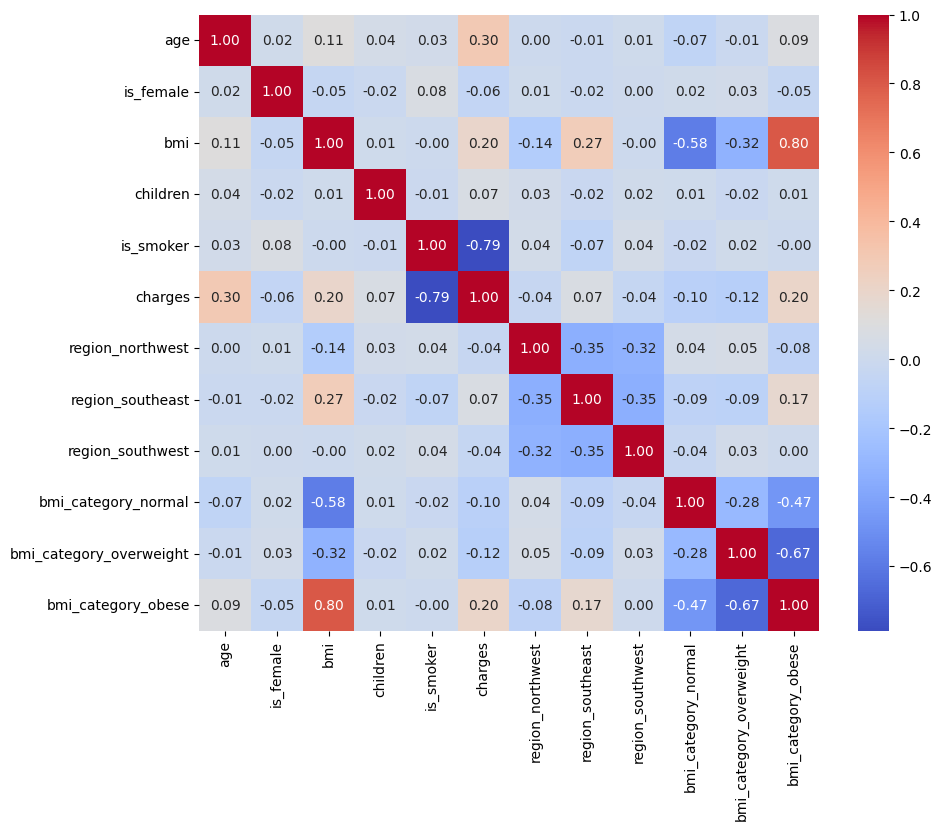

In [ ]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df_cleaned.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.show()

In [ ]:
from scipy.stats import pearsonr
import pandas as pd

selected_features = [col for col in df_cleaned.columns if col != 'charges']

correlations = {}

for feature in selected_features:
    r, p = pearsonr(df_cleaned[feature], df_cleaned['charges'])
    correlations[feature] = r

correlation_df = pd.DataFrame(
    correlations.items(),
    columns=['Feature', 'Pearson Correlation']
)

correlation_df = correlation_df.sort_values(
    by='Pearson Correlation',
    ascending=False
)

print(correlation_df)

                    Feature  Pearson Correlation
0                       age             0.298309
10       bmi_category_obese             0.200348
2                       bmi             0.196236
6          region_southeast             0.073577
3                  children             0.067390
5          region_northwest            -0.038695
7          region_southwest            -0.043637
1                 is_female            -0.058046
8       bmi_category_normal            -0.104042
9   bmi_category_overweight            -0.120601
4                 is_smoker            -0.787234


In [ ]:
df_cleaned.columns


Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_normal', 'bmi_category_overweight', 'bmi_category_obese'],
      dtype='object')

In [ ]:

cat_features = [
    'is_female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_normal', 'bmi_category_overweight', 'bmi_category_obese'
]

In [ ]:
from scipy.stats.distributions import alpha
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'], q=4, labels=False)
chi2_results ={}

for col in cat_features:
  contingency = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
  chi2_stat, p_val, _, _ = chi2_contingency(contingency)
  decision = 'Reject Null(Keep Feature)' if p_val < alpha else 'Accept Null(Drop Feature)'
  chi2_results[col] ={
      'chi2_statustic': chi2_stat,
      'p_value' : p_val,
      'Decision' : decision
  }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statustic,p_value,Decision
is_smoker,848.219178,0.0,Reject Null(Keep Feature)
region_southeast,15.998167,0.001135,Reject Null(Keep Feature)
is_female,10.258784,0.01649,Reject Null(Keep Feature)
bmi_category_obese,8.515711,0.036473,Reject Null(Keep Feature)
region_southwest,5.091893,0.165191,Accept Null(Drop Feature)
bmi_category_overweight,4.25149,0.235557,Accept Null(Drop Feature)
bmi_category_normal,3.708088,0.29476,Accept Null(Drop Feature)
region_northwest,1.13424,0.768815,Accept Null(Drop Feature)


In [ ]:
final_df = df_cleaned[['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges', 'region_southeast', 'bmi_category_obese']]

In [ ]:
final_df

,age,is_female,bmi,children,is_smoker,charges,region_southeast,bmi_category_obese
0,-1.440418,1,-0.517949,-0.909234,0,16884,0,0
1,-1.511647,0,0.462463,-0.079442,1,1725,1,1
2,-0.799350,0,0.462463,1.580143,1,4449,1,1
3,-0.443201,0,-1.334960,-0.909234,1,21984,0,0
4,-0.514431,0,-0.354547,-0.909234,1,3866,0,0
...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,1,10600,0,1
1334,-1.511647,1,0.135659,-0.909234,1,2205,0,1
1335,-1.511647,1,0.952670,-0.909234,1,1629,1,1
1336,-1.297958,1,-0.844753,-0.909234,1,2007,0,0
